# 3. More Radiation

In [34]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import trapezoid

## Part 1

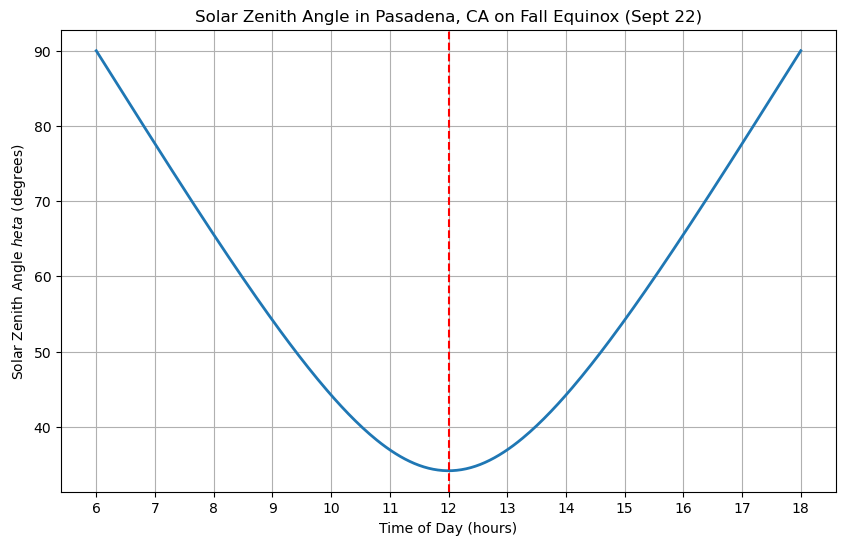

In [9]:
# Latitude for Pasadena, CA
phi_deg = 34.15  
phi_rad = np.deg2rad(phi_deg)

# Declination angle for fall equinox is 0 (Schneider section 3.4.1)
delta_deg = 0.0
delta_rad = np.deg2rad(delta_deg)

# We plot from sunrise (6:00) to sunset (18:00)
time_of_day = np.linspace(6, 18, 300)

# Calculate hour angle: eta = 15 degrees * (t - 12 hours) 
# (Schneider section 3.4.1)
hour_angle_deg = 15 * (time_of_day - 12)
hour_angle_rad = np.deg2rad(hour_angle_deg)

# Calculate zenith angle using Eq. 3.18 from Schneider section 3.4.1
# cos(theta) = sin(phi)sin(delta) + cos(phi)cos(delta)cos(eta)
cos_theta = (np.sin(phi_rad) * np.sin(delta_rad)) + \
            (np.cos(phi_rad) * np.cos(delta_rad) * np.cos(hour_angle_rad))

# Convert to degrees
zenith_angle_deg = np.rad2deg(np.arccos(cos_theta))

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(time_of_day, zenith_angle_deg, linewidth=2)
plt.xlabel("Time of Day (hours)")
plt.ylabel("Solar Zenith Angle $\theta$ (degrees)")
plt.title("Solar Zenith Angle in Pasadena, CA on Fall Equinox (Sept 22)")
plt.xticks(np.arange(6, 19, 1)) # Ticks every hour
plt.axvline(12, color='red', linestyle='--')
plt.grid(True)

## Part 2

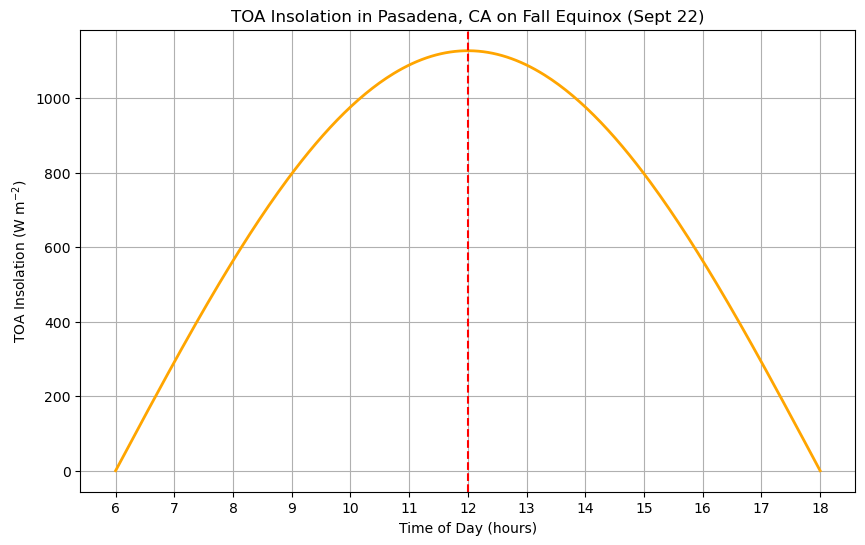

In [ ]:
S_0 = 1362 # Total Solar Irradiance (W/m^2)

# Calculate TOA insolation (Schneider section 3.4, Eq. 3.15)
# F = S * cos(theta) 
toa_insolation = S_0 * cos_theta

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(time_of_day, toa_insolation, linewidth=2, color='orange')
plt.xlabel("Time of Day (hours)")
plt.ylabel("TOA Insolation (W m$^{-2}$)")
plt.title("TOA Insolation in Pasadena, CA on Fall Equinox (Sept 22)")
plt.xticks(np.arange(6, 19, 1)) # Ticks every hour
plt.axvline(12, color='red', linestyle='--', label='Solar Noon (12:00 PM)')
plt.grid(True)

## Part 3

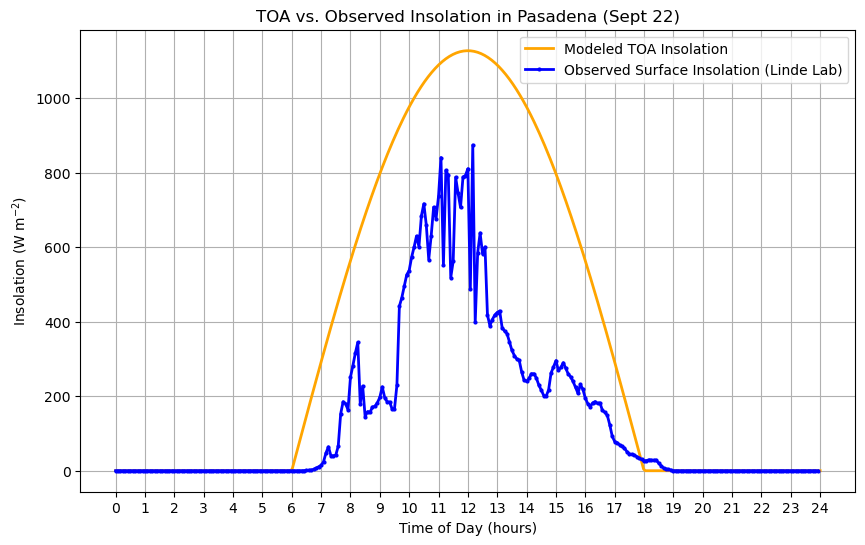

In [28]:
# Function to convert time to decimal hours
def time_to_decimal(time_str):
    _, time = time_str.split()
    hours, minutes = map(int, time.split(':'))
    return hours + minutes / 60.0

# Load observed data
data = pd.read_csv('2023-09-22-Temp.csv')
# Convert 'Time' column
data['Decimal Time'] = data['Time'].apply(time_to_decimal)
observed_time = data['Decimal Time']
observed_insolation = data['Insolation']

# Use a consistent time array for the model
model_time = np.linspace(0, 24, 400) # Full 24-hour cycle
hour_angle_deg = 15 * (model_time - 12) # Model assumes noon at 12:00
hour_angle_rad = np.deg2rad(hour_angle_deg)

cos_theta = (np.sin(phi_rad) * np.sin(delta_rad)) + \
            (np.cos(phi_rad) * np.cos(delta_rad) * np.cos(hour_angle_rad))
            
# When cos_theta < 0, sun is set. Clamp at 0.
cos_theta[cos_theta < 0] = 0.0

# Model TOA insolation
toa_insolation = S_0 * cos_theta

# Plot both model and observed data
plt.figure(figsize=(10, 6))
plt.plot(model_time, toa_insolation, linewidth=2, color='orange', 
         label='Modeled TOA Insolation')
plt.plot(observed_time, observed_insolation, linewidth=2, color='blue', 
         linestyle='-', marker='.', markersize=4, 
         label='Observed Surface Insolation (Linde Lab)')

plt.xlabel("Time of Day (hours)")
plt.ylabel("Insolation (W m$^{-2}$)")
plt.title("TOA vs. Observed Insolation in Pasadena (Sept 22)")
plt.xticks(np.arange(0, 25, 1)) # Ticks every hour
plt.legend()
plt.grid(True)

## Part 4

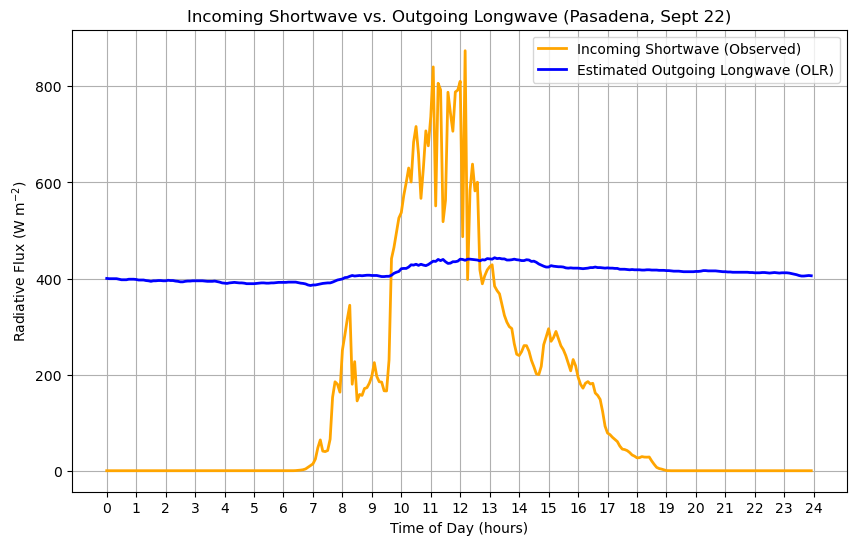

In [ ]:
# Convert temperature to Kelvin
temp_kelvin = data['Temperature'] + 273.15
sigma = 5.67e-8 # Stefan-Boltzmann constant (W m^-2 K^-4)
epsilon = 1.0   # Assume emissivity (epsilon) = 1 (blackbody)

# Calculate OLR using Stefan-Boltzmann Law: OLR = epsilon * sigma * T^4
olr = epsilon * sigma * (temp_kelvin**4)

# Plot both datasets
plt.figure(figsize=(10, 6))

# Plot Incoming Shortwave (Observed Insolation)
plt.plot(data['Decimal Time'], observed_insolation, linewidth=2, 
         color='orange', label='Incoming Shortwave (Observed)')
            
# Plot Outgoing Longwave (Calculated)
plt.plot(data['Decimal Time'], olr, linewidth=2, color='blue', 
            label='Estimated Outgoing Longwave (OLR)')

plt.xlabel("Time of Day (hours)")
plt.ylabel("Radiative Flux (W m$^{-2}$)")
plt.title("Incoming Shortwave vs. Outgoing Longwave (Pasadena, Sept 22)")
plt.xticks(np.arange(0, 25, 1)) # Ticks every hour
plt.legend()
plt.grid(True)

## Part 5

In [ ]:
# Convert time to seconds for Joules
time_seconds = data['Decimal Time'] * 3600.0

# trapezoid(y, x) computes the integral of y(x) dx
# Units are (W/m^2) * (s) = J/m^2
total_shortwave_energy = trapezoid(observed_insolation, time_seconds)
total_longwave_energy = trapezoid(olr, time_seconds)

# Convert to MegaJoules (MJ) for readability
total_sw_mj = total_shortwave_energy / 1e6
total_lw_mj = total_longwave_energy / 1e6

print(f"Total Incoming Shortwave Energy: {total_sw_mj:.2f} MJ/m^2")
print(f"Total Outgoing Longwave Energy: {total_lw_mj:.2f} MJ/m^2")

Total Incoming Shortwave Energy: 12.81 MJ/m^2
Total Outgoing Longwave Energy: 35.45 MJ/m^2
